In [2]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point
import folium
import matplotlib.pyplot as plt
import seaborn as sns

import importlib
import sim_utils

# SIM_UTILS.PY
importlib.reload(sim_utils)
from sim_utils import normalize

### Import and clean the layer containing Quebec boundaries
At this point, we get rid of most columns but "ARS_NM_ARR", which represents the district, and "geometry", which codifies geometrical information. Column ARS_NM_ARR will be renamed as "district" to ease the analysis. 

In [6]:
# 2. Upload boundaries
limits_raw = gpd.read_file(r"C:\Users\jesarauj001\OneDrive - INRS\Desktop\Geosatial Opimization Project\Layers\Raw layers\LIMITS_Qc.shp") 
limits_raw['district'] = limits_raw['ARS_NM_ARR']
city_limits = limits_raw[['district','geometry']]

# Reproyect to WGS84
city_limits = city_limits.to_crs(epsg=4326)

city_limits.head()

,district,geometry
0,Les Rivières,"POLYGON ((-71.26261 46.83542, -71.26082 46.833..."
1,La Haute-Saint-Charles,"MULTIPOLYGON (((-71.40996 46.95956, -71.40973 ..."
2,La Cité-Limoilou,"POLYGON ((-71.26082 46.83348, -71.26261 46.835..."
3,Charlesbourg,"POLYGON ((-71.32408 46.94312, -71.3239 46.9429..."
4,Sainte-Foy - Sillery - Cap-Rouge,"POLYGON ((-71.49475 46.80328, -71.49472 46.803..."


### Import the layer containing locations where HA occured

In [7]:
#points = gpd.read_file(r"C:\Users\jesarauj001\Downloads\Quebec bounds\GIS PROJECT\POINTS.shp")
points = gpd.read_file(r"C:\Users\jesarauj001\OneDrive - INRS\Desktop\Geosatial Opimization Project\Layers\Raw layers\POINTS.shp")

points['latitude'] = points.geometry.y
points['longitude'] = points.geometry.x
points['district'] = points['ARS_NM_ARR']

points_clean = points[['latitude','longitude','geometry']]
points_clean.tail()

,latitude,longitude,geometry
895,46.806307,-71.046034,POINT (-71.04603 46.80631)
896,46.764180,-71.052933,POINT (-71.05293 46.76418)
897,46.814271,-71.087120,POINT (-71.08712 46.81427)
898,46.766163,-71.146836,POINT (-71.14684 46.76616)
899,46.752717,-71.114660,POINT (-71.11466 46.75272)


### Join both layers

In [8]:
spots = gpd.sjoin(
    points_clean,
    city_limits[['district', 'geometry']],
    how='left',
    predicate='intersects'
)

spots = spots.drop(columns=[ "index_right"])
spots.head()

,latitude,longitude,geometry,district
0,46.827113,-71.276280,POINT (-71.27628 46.82711),Les Rivières
1,46.845294,-71.318646,POINT (-71.31865 46.84529),Les Rivières
2,46.798383,-71.320059,POINT (-71.32006 46.79838),Les Rivières
3,46.828485,-71.299962,POINT (-71.29996 46.82849),Les Rivières
4,46.829910,-71.337420,POINT (-71.33742 46.82991),Les Rivières


## Generate artificial relevant data
### 1. AGE
indicating the age of the patient at the time of the event. To be consistence with the context of the problem we will utilize a log-nogmal distribution to skew the distribution towards older ages, at which heart attacks are more likely.

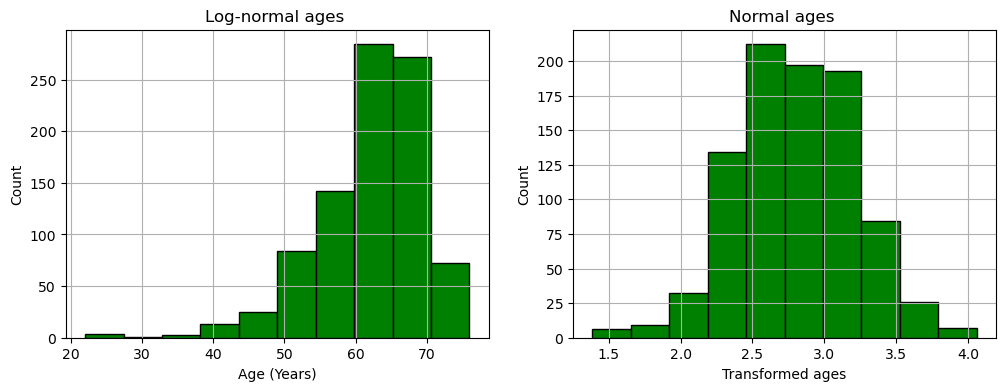

In [9]:
np.random.seed(12)

# 1. Parámeters
mean_subyacente = 2.8   # Controls how far the tail extends to the left
sigma_subyacente = 0.4  # Controls the dispersion of the tail

# 2. Generate log-normal data
raw_log_ages = np.random.lognormal(mean=mean_subyacente, sigma=sigma_subyacente, size=len(spots))

# 3. Reflecting the distribution using the maximum age (ex. 80 years)
max_age = 80
spots['age'] = (max_age - raw_log_ages).round().astype(int)

# --- COMPROBACIÓN MATEMÁTICA ---
# To restore the normal distribution, we subtract the age from the maximum age
# BEFORE applying the logarithm. This eliminates negative numbers.
normal_ages = np.log(max_age - spots['age'])

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.hist(spots['age'], color='green' , edgecolor="black")

plt.title('Log-normal ages ')
plt.xlabel('Age (Years)')
plt.ylabel('Count')
plt.grid()

plt.subplot(1,2,2)
plt.hist(normal_ages, color='green', edgecolor="black")
plt.title('Normal ages ')
plt.xlabel('Transformed ages')
plt.ylabel('Count')
plt.grid()
plt.show()

## 2. Disease 
indicating whether the patient suffers from any illness and which.This is a factor with 5 levels: 
1) DBT: Diabetes (30%)
2) HYP: Hypertension (10%)
3) AST: Asthma (25%)
4) CAD: Coronary artery disease (5%)
6) None: No illness (30%)

Percentages represent the fraction of the sample having those illnessess.

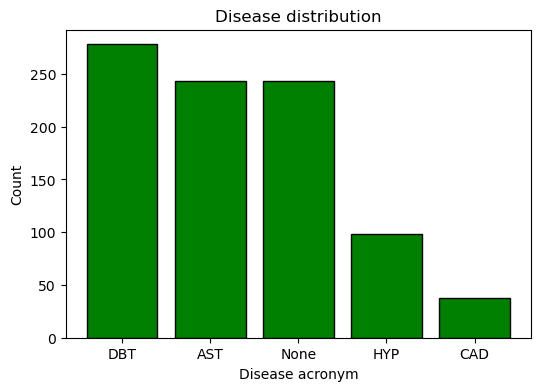

In [10]:
np.random.seed(2)
spots['disease'] = np.random.choice(['DBT','HYP','AST','CAD','None'], size=len(points), p=[0.3, 0.1, 0.25, 0.05,0.3])

# contar categorías
counts = spots['disease'].value_counts()

# gráfico
plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values, color='green', edgecolor="black")

plt.xlabel("Disease acronym")
plt.ylabel("Count")
plt.title("Disease distribution")

plt.show()

## 3. income
Indicating the economic level of the patient. This is a contineous variable following a log-normal distribution skewed towards higher salaries, ranging from ~`~$33K` to `~$100K`

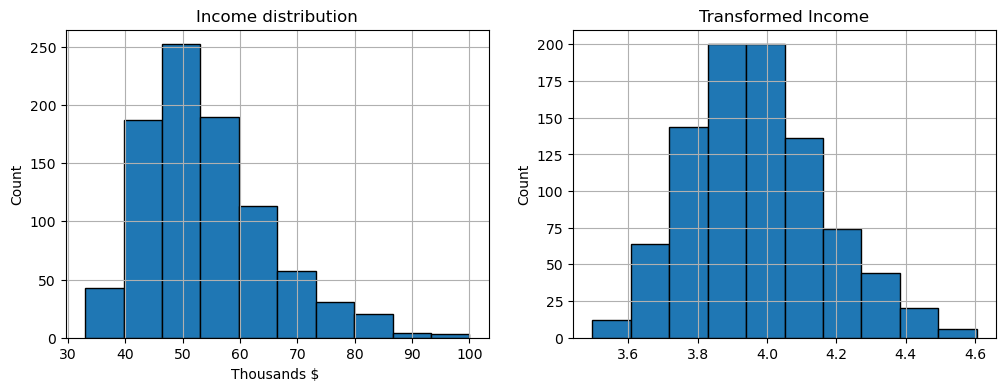

In [11]:
import numpy as np

np.random.seed(4)

# 1. generar log-normal base
raw_income = np.random.lognormal(mean=10.5, sigma=0.35, size=len(points))

# 2. escalar a rango [33k, 100k]
min_income = 33
max_income = 100

# normalización min-max
income_scaled = (raw_income - raw_income.min()) / (raw_income.max() - raw_income.min())
income = min_income + income_scaled * (max_income - min_income)

spots['income'] = income

normal_income = np.log(spots['income'])

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
spots.income.hist(edgecolor="black")
plt.xlabel("Thousands $ ")
plt.ylabel("Count")
plt.title("Income distribution")

plt.subplot(1,2,2)
normal_income.hist(edgecolor="black")
plt.ylabel("Count")
plt.title("Transformed Income")
plt.show()

## 4. Weight
Wight of the patient at the moment of the survey.

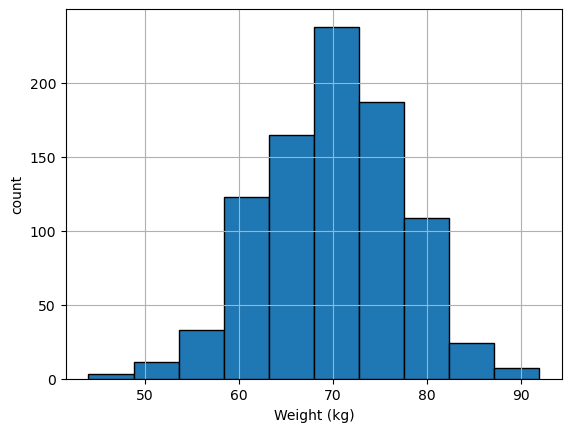

In [12]:
np.random.seed(12)
spots['weight'] = np.random.normal(loc=70, scale=7, size=len(points)).round().astype(int)
spots['weight'].hist(edgecolor="black")
plt.xlabel('Weight (kg)')
plt.ylabel('count')
plt.show()

## Risk factors

### 1.  Age factor $AF_i$
The age factor quantifies the relative vulnerability of an individual to heart attack events as a function of age. Given that risk increases with age, this relationship is captured through a normalized transformation of the observed age distribution.

The age factor is defined as:

$$
AF_i = \frac{a_i-a_{min}}{a_{max}-a_{min}} \ \ \ \in [0,1]
$$

Where $a_i$ is the age of the i-th patient and $a_{min}$ and $a_{max}$ are the minimum and maximum ages in the entire dataset respectively.

In [13]:
age_factor = normalize(normal_ages)
spots['AF'] = age_factor

### 2.  Weight factor $WF_i$
The weight factor represents the relative vulnerability associated with an individual’s body weight, under the assumption that higher body weight is associated with an increased risk of heart attack events.

The weight factor is defined as:

$$
WF_i = \frac{w_i-w_{min}}{w_{max}-w_{min}} \ \ \ \in [0,1]
$$

Where $w_i$ is the weight of the i-th patient and $w_{min}$ and $w_{max}$ are the minimum and maximum weights in the entire dataset respectively.

In [14]:
weight_factor = normalize(spots['weight'])  
spots['WF'] = weight_factor

### 3.  Economical factor $EF_i$
The economic factor captures the contribution of socioeconomic conditions to the individual risk of heart attack events, under the assumption that lower income levels are associated with higher vulnerability.

$$
EF_i = \frac{e_i-w_{min}}{e_{max}-e_{min}} \ \ \ \in [0,1]
$$

Where $e_i$ represents the income of the i-th patient and $w_{min}$ and $w_{max}$ are the minimum and maximum incomes in the entire dataset respectively.

In [15]:
income_factor = normalize(normal_income)
spots['EF'] = income_factor

### 4. Disease Factor $DF_i$
The disease factor represents the contribution of pre-existing medical conditions to the risk of heart attack. Unlike continuous variables, this factor is defined as a discrete mapping (step function) over a finite set of disease categories.

Let $d_i \in D$ denote the diagnosed condition of individual $i$, where:
$$
D=[DBT,HYP,CAD,AST,None]
$$

The disease factor $DF_i$ is defined as a step function:
$$
DF_i=f(d_i)
$$

Where:
- $0.25$ if $d_i=DBT$
- $0.35$ if $d_i=HYP$
- $0.10$ if $d_i=CAD$
- $0.40$ if $d_i=None$

In [16]:
# 2. Definir pesos para las enfermedades
disease_weights = {'DBT': 0.25, 'HYP': 0.35, 'CAD': 0.40, 'AST': 0.10, 'None': 0.0}
disease_factor = spots['disease'].map(disease_weights)
spots['DF'] = disease_factor

### Generate event distribution
Next, we will create a heart attacks distribution based on previous information using a Poisson proces. 
1) Age factor (older people is more prompt to suffer from a heart attack)
2) Temperature (higher temperatures enhances chances of heart attacks)
3) Disease risk (chronic diseases also enhances HA).

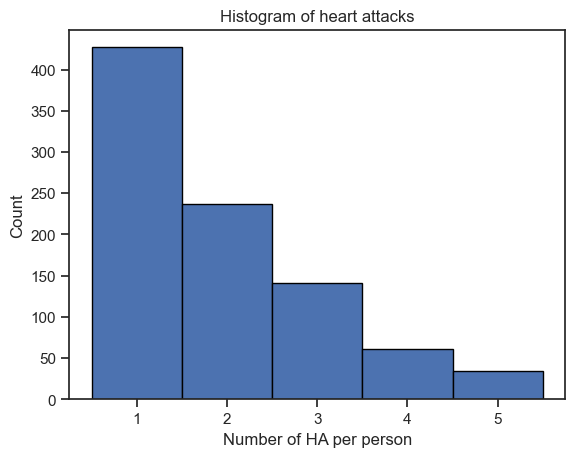

In [99]:
# Sumamos un valor base para que todos tengan probabilidad mínima > 0
lambda_events = np.exp(0.5*age_factor  + 0.5*disease_factor + 0.5*weight_factor - 0.1*income_factor)
#lambda_events = np.exp(0.3*age_factor  + 0.5*disease_factor + 0.2*weight_factor - 0.1*income_factor)

# Generamos los eventos siguiendo la distribución de Poisson
np.random.seed(14)
events = np.random.poisson(lambda_events)
events = np.clip(events, 1, 5) 
spots['events'] = events

plt.hist(
    spots['events'],
    bins=np.arange(0.5, 6.5, 1),
    edgecolor='black'
)

plt.xticks([1, 2, 3, 4, 5])
plt.title('Histogram of heart attacks')
plt.xlabel('Number of HA per person')
plt.ylabel('Count')
plt.show()

In [100]:
spots_out = spots[['age','weight','income','disease','events','district','geometry']]
spots_out.to_file("spots.gpkg", driver="GPKG")
city_limits.to_file("boundaries.gpkg", driver="GPKG")
#spots.to_file(
#    r"C:\Users\jesarauj001\OneDrive - INRS\Desktop\Geosatial Opimization Project\Site_location\spots.shp",
#    driver="ESRI Shapefile"
#)

In [96]:
spots_out.head()

,events,district,geometry
0,3,Les Rivières,POINT (-71.27628 46.82711)
1,2,Les Rivières,POINT (-71.31865 46.84529)
2,2,Les Rivières,POINT (-71.32006 46.79838)
3,2,Les Rivières,POINT (-71.29996 46.82849)
4,0,Les Rivières,POINT (-71.33742 46.82991)


In [97]:
spots.head()

,latitude,longitude,geometry,district,age,disease,income,weight,AF,WF,EF,DF,events,age_factor,disease_factor,weight_factor,income_factor
0,46.827113,-71.276280,POINT (-71.27628 46.82711),Les Rivières,60,AST,52.134220,73,0.601851,0.604167,0.412492,0.10,3,0.601851,0.10,0.604167,0.412492
1,46.845294,-71.318646,POINT (-71.31865 46.84529),Les Rivières,67,DBT,57.211902,65,0.440759,0.437500,0.496323,0.25,2,0.440759,0.25,0.437500,0.496323
2,46.798383,-71.320059,POINT (-71.32006 46.79838),Les Rivières,62,AST,42.991846,72,0.562451,0.583333,0.238578,0.10,2,0.562451,0.10,0.583333,0.238578
3,46.828485,-71.299962,POINT (-71.29996 46.82849),Les Rivières,72,AST,59.658490,58,0.259203,0.291667,0.534093,0.10,2,0.259203,0.10,0.291667,0.534093
4,46.829910,-71.337420,POINT (-71.33742 46.82991),Les Rivières,58,AST,47.622527,75,0.637492,0.645833,0.330848,0.10,0,0.637492,0.10,0.645833,0.330848
